# Description

### Architecture and Strategy Summary

This notebook implements a **hierarchical** deep learning classification pipeline composed of three **independent binary classifiers (C1, C2, C3)** trained using **5-fold cross-validation**. Each classifier outputs a single logit and is optimized with *AdamW*, which empirically outperformed Lion in our experiments (≈ +0.01 macro-F1). To improve robustness against class imbalance, training employs a *WeightedRandomSampler*, while *early stopping* is used to prevent overfitting. Image preprocessing is shared across all tasks and includes *ROI* extraction using segmentation masks, *Reinhard color normalization*, and resizing to a fixed resolution. During training, stochastic data augmentation (random crops and AutoAugment) was preferred over deterministic transforms, yielding a measurable improvement in performance (≈ +0.035 macro-F1).

Importantly, the **decision threshold** is not fixed: for each fold, an optimal threshold is selected on the validation set by maximizing macro-F1 and stored alongside the model weights. At inference time, predictions are generated using an ensemble and **Test-Time Augmentation** (TTA) strategy, where outputs are averaged across folds and augmented views, and the stored fold-specific thresholds are applied to enforce consistency with the *training distribution*.

The hierarchical decision process is structured as follows: C1 performs triage between Luminal and Aggressive tumor groups; samples predicted as Luminal are passed to C2 for Luminal A vs. Luminal B subtyping, while samples predicted as Aggressive are routed to C3 for HER2(+) vs. Triple negative subtyping. This cascaded design reduces task complexity at each stage, improves class separability, and aligns the training distribution with the clinical decision flow.


best results by now are
- 0.3921
- 0.3874

P.S. "Triple negative", not "Triple Negative"

P.S.2: The C2 values were changed and produced unexpected result. Maybe we can submit it.
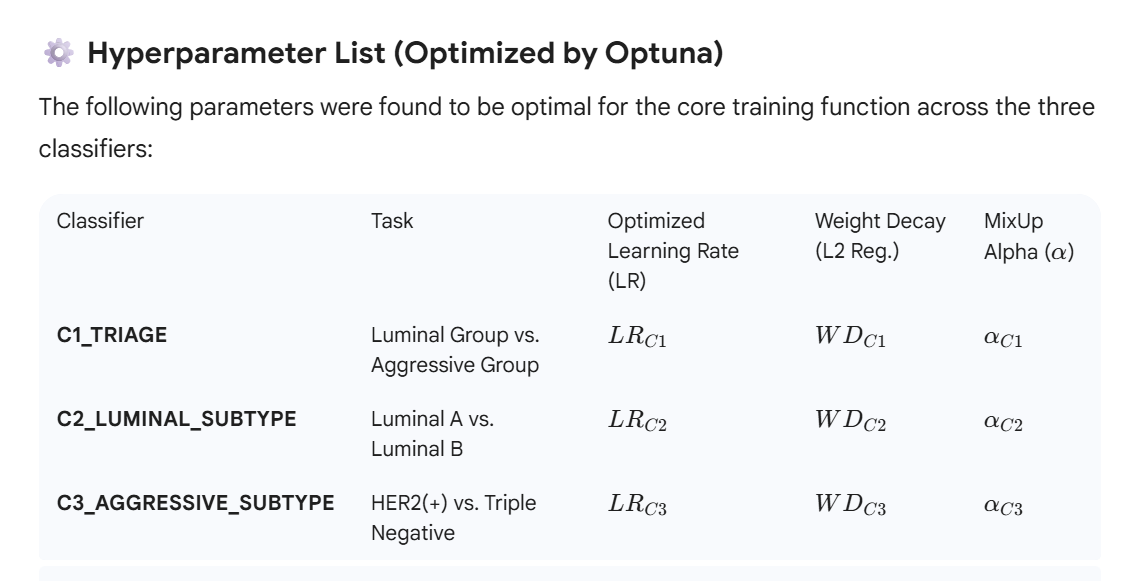

# Start

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision.transforms import AutoAugment, AutoAugmentPolicy 

PRECOMPUTED_DIR = '/kaggle/working/precomputed_rois' # The location to save processed images


In [15]:
import random
def set_seed(seed: int = 19):
    # Python
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic behavior (important)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # PyTorch >= 1.8
    torch.use_deterministic_algorithms(False)

    print(f"✅ Global seed set to {seed}")

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

SEED = 19
set_seed(SEED)
g = torch.Generator()
g.manual_seed(SEED)


✅ Global seed set to 19


In [5]:
# --- 1. CONFIGURAZIONE ---
def find_paths():
    base_train = '/kaggle/input/dataset/dataset'
    # Cerca la cartella corretta per il test (che ha lo spazio nel nome)
    test_root = '/kaggle/input/test-data/test_data'
    # for root, dirs, files in os.walk('/kaggle/input'):
    #     if root.endswith("test-data/test_data"):
    #         test_root = root
    #         break
            
    if test_root is None:
        raise ValueError("Impossibile trovare la cartella test_data/images")

    return {
        'train_img': os.path.join(base_train, 'images'),
        'train_mask': os.path.join(base_train, 'masks'),
        'labels': os.path.join(base_train, 'train_labels.csv'),
        'test_img': os.path.join(test_root, 'test_img'),
        'test_mask': os.path.join(test_root, 'test_mask')
    }

PATHS = find_paths()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Iperparametri Ottimizzati
IMG_SIZE = 256
BATCH_SIZE = 64
N_FOLDS = 5
EPOCHS = 50


In [6]:


# --- CLASSIFIER CONFIGURATIONS ---
# Define the three distinct tasks and their initial hyperparameters
CLASSIFIER_CONFIGS = {
    # C1: Triage (Aggressive vs. Luminal Group)
    'C1_TRIAGE': {
        'key': 'C1_TRIAGE',
        'name': 'C1_TRIAGE: Luminal vs. Aggressive',
        'group_0': ['Luminal A', 'Luminal B'],        # Class 0
        'group_1': ['HER2(+)', 'Triple negative'],     # Class 1
        'label_col': 'C1_label',
        'class_names': ['Luminal Group', 'Aggressive Group'],
        'hparams':{
            'LR': 5e-5,          # Lower LR for better convergence on subtle features
            'WEIGHT_DECAY': 3e-2,
            'MIXUP_ALPHA': 0.2   # Increased MixUp for better generalization
        }
    },
    
    # C2: Luminal Subtyping (Requires data where label is Luminal A or B)
    'C2_LUMINAL_SUBTYPE': {
        'key': 'C2_LUMINAL_SUBTYPE',
        'name': 'C2_LUMINAL_SUBTYPE: Luminal A vs. Luminal B',
        'group_0': ['Luminal A'],                      # Class 0
        'group_1': ['Luminal B'],                      # Class 1
        'label_col': 'C2_label',
        'class_names': ['Luminal A', 'Luminal B'],
        'hparams': {
            'LR': 5e-5,          # Very low LR is usually needed for this subtle task
            'WEIGHT_DECAY': 3e-2,    # Increased regularization for the subtle task
            'MIXUP_ALPHA': 0.7       # Max MixUp to fight overfitting on a small subset
        }
    },
    
    # C3: Aggressive Subtyping (Requires data where label is HER2 or TN)
    'C3_AGGRESSIVE_SUBTYPE': {
        'key': 'C3_AGGRESSIVE_SUBTYPE',
        'name': 'C3_AGGRESSIVE_SUBTYPE: HER2(+) vs. Triple Negative',
        'group_0': ['HER2(+)'],                        # Class 0
        'group_1': ['Triple negative'],                # Class 1
        'label_col': 'C3_label',
        'class_names': ['HER2(+)', 'Triple negative'],
        'hparams': {
            'LR': 1e-4,          # Can use a slightly higher LR since the task is clearer
            'WEIGHT_DECAY': 1e-2,    # Less regularization needed
            'MIXUP_ALPHA': 0.4       # Standard MixUp
        }
    }
}

In [7]:
# --- 2. DATASET & PREPROCESSING ---
class ReinhardNormalizer:
    """Normalizzazione Colore per standardizzare i vetrini"""
    def __init__(self):
        self.target_mean = np.array([148.60, 169.30, 105.47])
        self.target_std = np.array([41.56, 11.23, 14.39])

    def __call__(self, img_rgb):
        try:
            img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype("float32")
            img_mean = np.mean(img_lab, axis=(0,1))
            img_std = np.std(img_lab, axis=(0,1)) + 1e-5
            img_lab = (img_lab - img_mean) / img_std
            img_lab = img_lab * self.target_std + self.target_mean
            img_lab = np.clip(img_lab, 0, 255).astype("uint8")
            return cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)
        except:
            return img_rgb

reinhard = ReinhardNormalizer()

def get_bbox_from_mask(mask):
    if np.sum(mask) == 0: return None
    rows, cols = np.where(mask > 0)
    return np.min(rows), np.max(rows), np.min(cols), np.max(cols)


# --- 2. DATASET & PREPROCESSING (Modified TissueDataset) ---
# ... (ReinhardNormalizer and get_bbox_from_mask remain the same) ...

class TissueDataset(Dataset):
    def __init__(self, dataframe, precomputed_dir, transform=None, is_test=False, target_label_column='C1_label'):
        self.df = dataframe
        # This directory now contains the final, preprocessed images
        self.precomputed_dir = precomputed_dir 
        self.transform = transform
        self.is_test = is_test
        self.target_label_column = target_label_column 

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # FIX: Always use 'sample_index' as the column for the file name.
        # The 'filename' column does not exist in the processed test DataFrame.
        img_name = row['sample_index'] 
        
        # --- FAST READ FROM PRECOMPUTED FILE ---
        img_path = os.path.join(self.precomputed_dir, img_name)
        
        try:
            # ... (rest of the logic remains the same) ...
            image = Image.open(img_path).convert("RGB")
        except:
            image = torch.zeros(3, IMG_SIZE, IMG_SIZE)
            # You must ensure the return type matches the expected structure (image, name/label)
            if self.is_test: return image, row['sample_index']
            else: return image, torch.tensor(row[self.target_label_column], dtype=torch.long)
            
        # Apply only the PyTorch/AutoAugment transforms (fast and GPU-friendly)
        if self.transform: image = self.transform(image)
        
        if self.is_test: 
            return image, row['sample_index'] # FIX: Return 'sample_index' as the name
        else: 
            label = row[self.target_label_column]
            return image, torch.tensor(label, dtype=torch.long)

In [8]:
# --- 3. TRANSFORMS & MIXUP ---
#this augmentation was the best one for f1 = 0.3803

def get_transforms(): 
    train_trans = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)), 
        
        # *** AutoAugment for stronger generalization ***
        AutoAugment(policy=AutoAugmentPolicy.IMAGENET),
        
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    val_trans = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return train_trans, val_trans

def mixup_data(x, y, alpha=1.0):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(DEVICE)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


In [9]:
# --- 4. MODELLO: EfficientNet-B0 (Pretrained) ---
def get_model(num_classes):
    # Usiamo B0 perché con 581 immagini, B3 o superiori overfittano troppo velocemente
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    
    # Custom Head
    in_features = model.classifier[1].in_features
    
    # EfficientNet already has a Dropout layer (0.2) before this.
    model.classifier = nn.Linear(in_features, num_classes) # num_classes should be 1
    
    return model.to(DEVICE)

In [10]:
# --- 5 PRECOMPUTATION FUNCTION ---

def preprocess_and_save_images(df, paths, output_dir, img_size):
    """
    Applies ROI extraction and Reinhard normalization once, saving the result 
    to a new output_dir so the DataLoader only handles fast reads and PyTorch transforms.
    """
    print("Starting precomputation and saving of processed ROIs...")
    
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Initialize the Reinhard Normalizer
    reinhard = ReinhardNormalizer()
    
    # We will track which images were successfully processed
    processed_indices = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing Images"):
        img_name = row['sample_index']
        mask_name = img_name.replace("img", "mask")
        
        img_path = os.path.join(paths['train_img'], img_name)
        mask_path = os.path.join(paths['train_mask'], mask_name)
        output_path = os.path.join(output_dir, img_name)
        
        try:
            # 1. Read and Convert
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            
            # 2. ROI Extraction (using mask)
            if mask is not None:
                bbox = get_bbox_from_mask(mask)
                if bbox:
                    y_min, y_max, x_min, x_max = bbox
                    image = image[y_min:y_max+1, x_min:x_max+1]
            
            # 3. Color Normalization
            image = reinhard(image)
            
            # 4. Resize and Save (as PNG for better quality than JPEG)
            # Use PIL for robust and standard resizing for saving
            image_pil = Image.fromarray(image)
            # Resize the cropped ROI to the target size before saving
            image_resized = image_pil.resize((img_size, img_size), Image.Resampling.LANCZOS)
            
            image_resized.save(output_path, "PNG")
            processed_indices.append(idx)
            
        except Exception as e:
            # Handle cases where image/mask read fails
            print(f"Skipping image {img_name} due to error: {e}")
            continue

    # Return the filtered dataframe containing only successfully processed images
    return df.iloc[processed_indices].reset_index(drop=True)


def setup_data_and_preprocess():
    """
    Reads labels, performs binary grouping, runs the heavy CPU precomputation
    (ROI extraction and Reinhard normalization), and returns the filtered DataFrame.
    """
    print("--- 🧠 Data Setup & Preprocessing Started ---")
    
    # 1. Load Data and Filter by Existence (Unchanged)
    df = pd.read_csv(PATHS['labels'])
    valid_mask = df['sample_index'].apply(lambda x: os.path.exists(os.path.join(PATHS['train_img'], x)))
    df = df[valid_mask].reset_index(drop=True)

    # ---------- C1: TRIAGE (Luminal vs Aggressive) ----------
    df['C1_label'] = -1

    df.loc[df['label'].isin(['Luminal A', 'Luminal B']), 'C1_label'] = 0
    df.loc[df['label'].isin(['HER2(+)', 'Triple negative']), 'C1_label'] = 1

    # ---------- C2: LUMINAL SUBTYPE (only if C1 == 0) ----------
    df['C2_label'] = -1
    mask_luminal = df['C1_label'] == 0

    df.loc[mask_luminal & (df['label'] == 'Luminal A'), 'C2_label'] = 0
    df.loc[mask_luminal & (df['label'] == 'Luminal B'), 'C2_label'] = 1

    # ---------- C3: AGGRESSIVE SUBTYPE (only if C1 == 1) ----------
    df['C3_label'] = -1
    mask_aggressive = df['C1_label'] == 1

    df.loc[mask_aggressive & (df['label'] == 'HER2(+)'), 'C3_label'] = 0
    df.loc[mask_aggressive & (df['label'] == 'Triple negative'), 'C3_label'] = 1

    # # 2. Multi-Task Labeling: Create 3 Binary Labels (NEW LOGIC)
    # for key, config in CLASSIFIER_CONFIGS.items():
    #     # Combine all classes used in this task
    #     all_classes_in_task = config['group_0'] + config['group_1']
        
    #     # Filter out rows that are not relevant to this task for C2 and C3
    #     # For C1, all rows are relevant. For C2/C3, irrelevant rows will be marked -1.
        
    #     def get_classifier_label(original_label):
    #         if original_label in config['group_0']:
    #             return 0
    #         elif original_label in config['group_1']:
    #             return 1
    #         else:
    #             return -1 # Mark rows irrelevant to this task
                
    #     df[config['label_col']] = df['label'].apply(get_classifier_label)

    # 3. Precompute ROIs, Resize, and Save (Unchanged)
    # The precomputation step doesn't care about the labels, only the images.
    df_final = preprocess_and_save_images(df, PATHS, PRECOMPUTED_DIR, IMG_SIZE)
    
    # Filter out any rows that failed precomputation
    # Note: df_final now contains all 3 label columns (C1_label, C2_label, C3_label)
    
    print(f"--- ✅ Precomputation Complete. Final images available: {len(df_final)} ---")
    return df_final

In [11]:
# --- 6. TRAINING LOOP ---

from sklearn.metrics import roc_curve, f1_score

def train_fold(fold, train_idx, val_idx, df, le, precomputed_dir, config):
    classifier_key = config['key']
    print(f"\n=== FOLD {fold+1}/{N_FOLDS} ===")
    patience = 20
    epochs_no_improve = 0
    
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)
    
    # Filter dataframes to only include relevant samples for this task (label != -1)
    train_df = train_df[train_df[config['label_col']] != -1].reset_index(drop=True)
    val_df = val_df[val_df[config['label_col']] != -1].reset_index(drop=True)
    
    # Check if the filtered dataframes still have samples
    if len(train_df) == 0 or len(val_df) == 0:
        print("Skipping fold: Insufficient data for this classifier's task.")
        return None, [], [] # Return placeholders if no data remains for this task
        
    # Class Balancing
    class_counts = train_df[config['label_col']].value_counts().sort_index().values    
    class_weights = 1. / class_counts
    sample_weights = [class_weights[l] for l in train_df[config['label_col']]]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
    
    train_loader = DataLoader(TissueDataset(train_df, precomputed_dir, get_transforms()[0], target_label_column=config['label_col']), 
                              batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, worker_init_fn=seed_worker,
    generator=g,pin_memory=True)
    val_loader = DataLoader(TissueDataset(val_df, precomputed_dir, get_transforms()[1], target_label_column=config['label_col']), 
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=2, worker_init_fn=seed_worker,
    generator=g,pin_memory=True)

    # 3. HParams (Use the config dictionary)
    HPARAMS = config['hparams']
    
    model = get_model(num_classes = 1)
    optimizer = optim.AdamW(model.parameters(), lr=HPARAMS['LR'], weight_decay = HPARAMS['WEIGHT_DECAY'])
    criterion = nn.BCEWithLogitsLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    history = {'t_loss': [], 'v_loss': [], 't_f1': [], 'v_f1': []}
    best_f1 = 0.0
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        t_preds, t_targets = [], []
        
        for imgs, lbls in tqdm(train_loader, desc=f"Ep {epoch+1}", leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            
            # --- MIXUP BLOCK ---
            lbls_float = lbls.float().unsqueeze(1)
            imgs, targets_a, targets_b, lam = mixup_data(imgs, lbls_float, HPARAMS['MIXUP_ALPHA'])
            out = model(imgs)
            loss = mixup_criterion(criterion, out, targets_a, targets_b, lam)
            
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            
            # Per le metriche usiamo l'argmax approssimato (non perfetto col mixup ma indicativo)
            t_preds.extend((torch.sigmoid(out) >= 0.5).long().reshape(-1).cpu().numpy())
            t_targets.extend(targets_a.round().long().reshape(-1).cpu().numpy()) # targets_a is float

        scheduler.step()
        
        # Validation (No Mixup)
        model.eval()
        v_loss = 0
        v_probs, v_targets = [], []
        
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                lbls_float = lbls.float().unsqueeze(1)
        
                out = model(imgs)
                v_loss += criterion(out, lbls_float).item()
        
                probs = torch.sigmoid(out).squeeze(1)
                v_probs.extend(probs.cpu().numpy())
                v_targets.extend(lbls.cpu().numpy())
                
                # v_preds.extend((torch.sigmoid(out) >= 0.5).long().reshape(-1).cpu().numpy())
                # v_targets.extend(lbls.reshape(-1).cpu().numpy())
        
        t_loss /= len(train_loader)
        v_loss /= len(val_loader)

        v_probs_np = np.array(v_probs)
        v_targets_np = np.array(v_targets)

        thresholds = np.linspace(0.3, 0.7, 41)
        f1s = [f1_score(v_targets, (v_probs >= t).astype(int), average="macro") for t in thresholds]
        
        best_idx = np.argmax(f1s)
        best_thresh = thresholds[best_idx]
        best_f1_epoch = f1s[best_idx]
        

        t_f1 = f1_score(t_targets, t_preds, average='macro') 
        
        history['t_loss'].append(t_loss); history['v_loss'].append(v_loss)
        history['t_f1'].append(t_f1); history['v_f1'].append(best_f1_epoch)
        
        print(
            f"Ep {epoch+1}: "
            f"V_Loss {v_loss:.3f} | "
            f"Best F1 {best_f1_epoch:.3f} @ t={best_thresh:.2f}"
        )
        # if v_f1 > best_f1:
        #     best_f1 = v_f1
        #     torch.save(model.state_dict(), f"{classifier_key}_fold_{fold}_best.pth") 

        if best_f1_epoch > best_f1:
            best_f1 = best_f1_epoch
            torch.save({
                "state_dict": model.state_dict(),  # save model weights
                "threshold": best_thresh,          # save adaptive threshold
                "best_f1": best_f1
            }, f"{classifier_key}_fold_{fold}_best.pth")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break
                    
    print(f"Best Val F1: {best_f1:.4f}")
    return history, None, None

In [12]:
def train_classifier(classifier_key, df_final, precomputed_dir):

    config = CLASSIFIER_CONFIGS[classifier_key]
    print(f"\n=======================================================")
    print(f"       STARTING TRAINING FOR: {config['name']}       ")
    print(f"       HPARAMS: {config['hparams']}  ")
    print(f"=======================================================")

    class_names = config['class_names']

    class DummyLabelEncoder:
        def __init__(self, names):
            self.classes_ = names
        def inverse_transform(self, predictions):
            return [self.classes_[p] for p in predictions]

    le = DummyLabelEncoder(class_names)

    df_task = df_final[df_final[config['label_col']] != -1].reset_index(drop=True)
    if len(df_task) == 0:
        print("No samples available for this classifier after filtering.")
        return None, le

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    histories = []

    for fold, (t_idx, v_idx) in enumerate(skf.split(df_task, df_task[config['label_col']])):
        h, _, _ = train_fold(fold, t_idx, v_idx, df_task, class_names, precomputed_dir, config)
        if h is not None:
            histories.append(h)

    if not histories:
        print("Training failed for all folds due to lack of data.")
        return None, le

    # ---- PLOTTING ----
    fig, axes = plt.subplots(N_FOLDS, 2, figsize=(12, 4*N_FOLDS))
    for i, h in enumerate(histories):
        axes[i][0].plot(h['t_loss'], label='Train')
        axes[i][0].plot(h['v_loss'], label='Val')
        axes[i][0].legend()
        axes[i][0].set_title(f'Fold {i+1} Loss')

        axes[i][1].plot(h['t_f1'], label='Train F1')
        axes[i][1].plot(h['v_f1'], label='Val F1 (best threshold)')
        axes[i][1].legend()
        axes[i][1].set_title(f'Fold {i+1} F1')

    plt.tight_layout()
    plt.show()

    return histories, le


In [13]:
# 1. Initial Setup (Call once)
DF_FINAL = setup_data_and_preprocess()

--- 🧠 Data Setup & Preprocessing Started ---
Starting precomputation and saving of processed ROIs...


Preprocessing Images: 100%|██████████| 581/581 [01:11<00:00,  8.15it/s]

--- ✅ Precomputation Complete. Final images available: 581 ---



       STARTING TRAINING FOR: C1_TRIAGE: Luminal vs. Aggressive       
       HPARAMS: {'LR': 5e-05, 'WEIGHT_DECAY': 0.03, 'MIXUP_ALPHA': 0.2}  

=== FOLD 1/5 ===


Ep 1: V_Loss 0.712 | Best F1 0.577 @ t=0.56


Ep 2: V_Loss 0.707 | Best F1 0.536 @ t=0.53


Ep 3: V_Loss 0.703 | Best F1 0.538 @ t=0.51


Ep 4: V_Loss 0.705 | Best F1 0.546 @ t=0.50


...

Ep 28: V_Loss 0.626 | Best F1 0.653 @ t=0.46


Ep 29: V_Loss 0.629 | Best F1 0.641 @ t=0.47


Ep 30: V_Loss 0.630 | Best F1 0.667 @ t=0.47


Ep 31: V_Loss 0.630 | Best F1 0.645 @ t=0.47


Ep 32: V_Loss 0.632 | Best F1 0.645 @ t=0.48
Early stopping triggered after 32 epochs.
Best Val F1: 0.6674


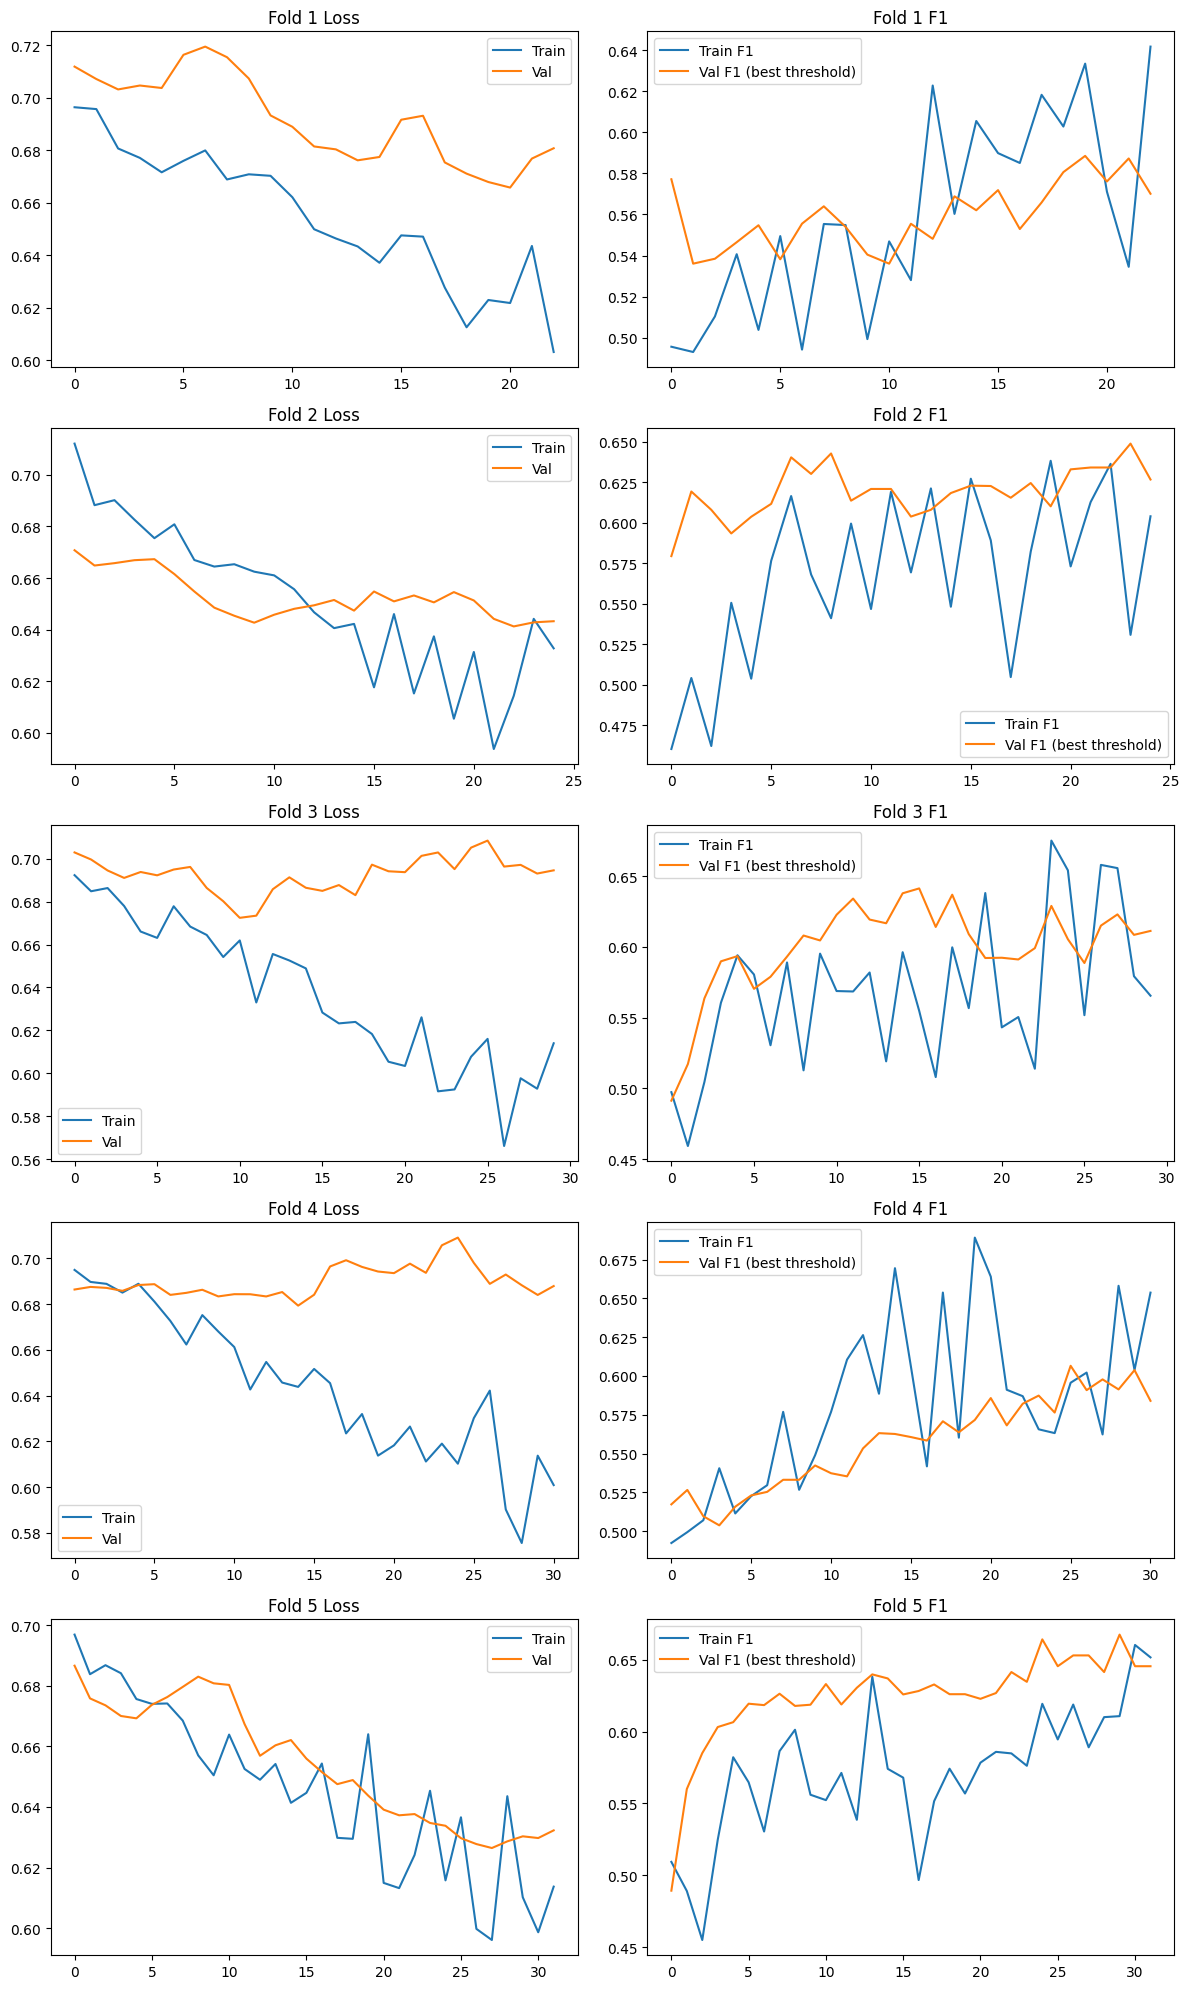

In [16]:
# 2. TRAINING (Called three times, one for each model)
# Train Classifier 1
preds_c1, le_c1 = train_classifier('C1_TRIAGE', DF_FINAL, PRECOMPUTED_DIR)

In [17]:
# ---- C1 label distribution check ----
label_col = 'C1_label'

print("\n=== C1 TRIAGE: Label Distribution ===")
counts = DF_FINAL[label_col].value_counts().sort_index()

for cls in [-1, 0, 1]:
    print(f"Class {cls}: {counts.get(cls, 0)} samples")

print("\nMeaning:")
print("  0 → Luminal Group")
print("  1 → Aggressive Group")
print(" -1 → Irrelevant (should be NONE for C1)")



=== C1 TRIAGE: Label Distribution ===
Class -1: 0 samples
Class 0: 362 samples
Class 1: 219 samples

Meaning:
  0 → Luminal Group
  1 → Aggressive Group
 -1 → Irrelevant (should be NONE for C1)



       STARTING TRAINING FOR: C2_LUMINAL_SUBTYPE: Luminal A vs. Luminal B       
       HPARAMS: {'LR': 5e-05, 'WEIGHT_DECAY': 0.03, 'MIXUP_ALPHA': 0.7}  

=== FOLD 1/5 ===


Ep 1: V_Loss 0.682 | Best F1 0.585 @ t=0.49


Ep 2: V_Loss 0.692 | Best F1 0.542 @ t=0.50


Ep 3: V_Loss 0.696 | Best F1 0.514 @ t=0.49


Ep 4: V_Loss 0.697 | Best F1 0.530 @ t=0.51


...

Ep 28: V_Loss 0.669 | Best F1 0.670 @ t=0.48


Ep 29: V_Loss 0.666 | Best F1 0.670 @ t=0.48


Ep 30: V_Loss 0.668 | Best F1 0.662 @ t=0.45


Ep 31: V_Loss 0.676 | Best F1 0.651 @ t=0.52


Ep 32: V_Loss 0.677 | Best F1 0.649 @ t=0.45
Early stopping triggered after 32 epochs.
Best Val F1: 0.6857


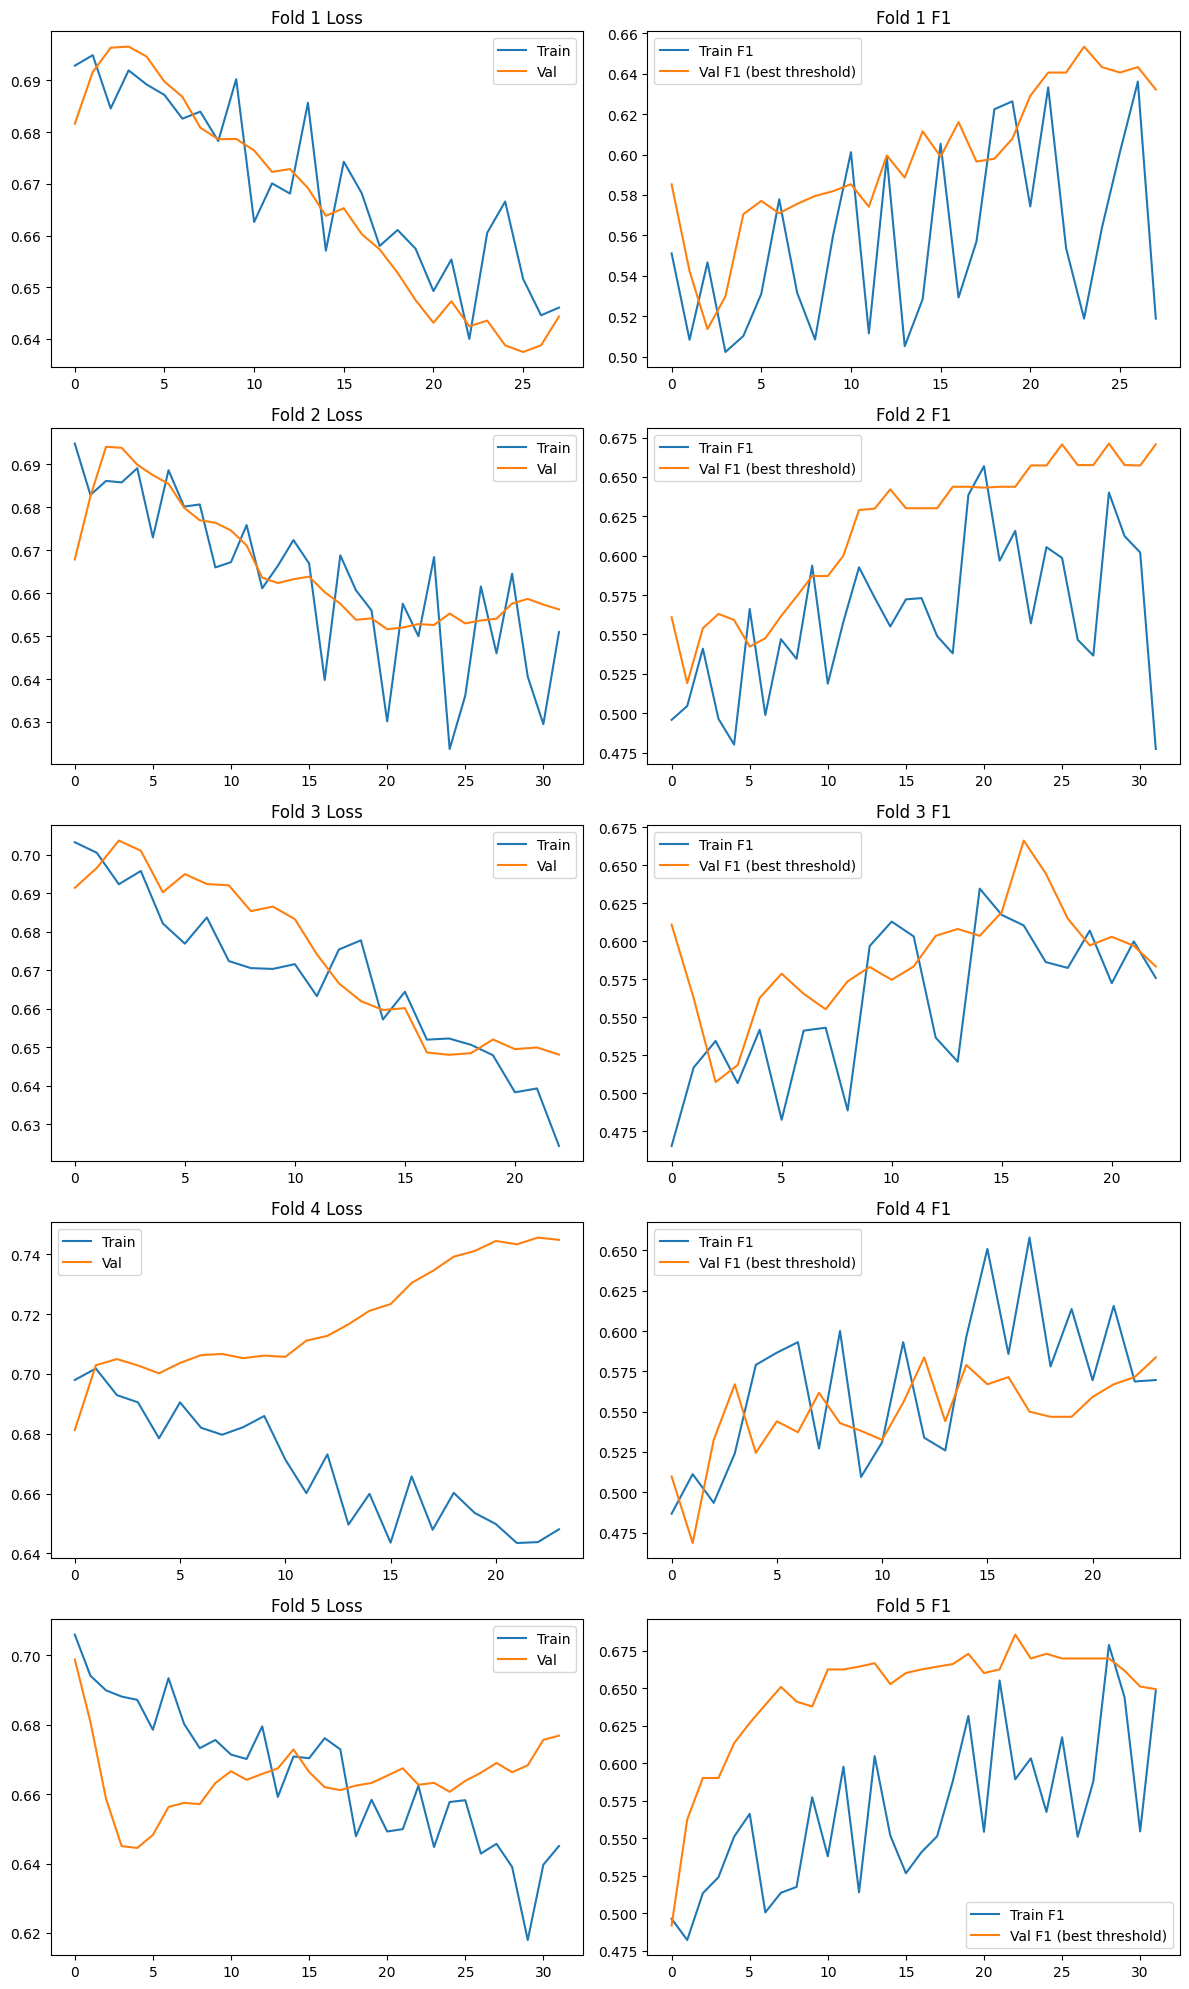

In [18]:
# Train Classifier 2 (Luminal Subtypes)
preds_c2, le_c2 = train_classifier('C2_LUMINAL_SUBTYPE', DF_FINAL, PRECOMPUTED_DIR)

In [19]:
# ---- C2 label distribution check ----
label_col = 'C2_label'

print("\n=== C2 LUMINAL SUBTYPE: Label Distribution ===")
counts = DF_FINAL[label_col].value_counts().sort_index()

for cls in [-1, 0, 1]:
    print(f"Class {cls}: {counts.get(cls, 0)} samples")

print("\nMeaning:")
print("  0 → Luminal A")
print("  1 → Luminal B")
print(" -1 → Non-luminal (HER2 / TN)")

# 0 ≈ 158

# 1 ≈ 204

# -1 ≈ 219



=== C2 LUMINAL SUBTYPE: Label Distribution ===
Class -1: 219 samples
Class 0: 158 samples
Class 1: 204 samples

Meaning:
  0 → Luminal A
  1 → Luminal B
 -1 → Non-luminal (HER2 / TN)



       STARTING TRAINING FOR: C3_AGGRESSIVE_SUBTYPE: HER2(+) vs. Triple Negative       
       HPARAMS: {'LR': 0.0001, 'WEIGHT_DECAY': 0.01, 'MIXUP_ALPHA': 0.4}  

=== FOLD 1/5 ===


Ep 1: V_Loss 0.682 | Best F1 0.563 @ t=0.51


Ep 2: V_Loss 0.679 | Best F1 0.546 @ t=0.48


Ep 3: V_Loss 0.681 | Best F1 0.531 @ t=0.50


Ep 4: V_Loss 0.676 | Best F1 0.542 @ t=0.47


...

Ep 17: V_Loss 0.710 | Best F1 0.522 @ t=0.41


Ep 18: V_Loss 0.717 | Best F1 0.533 @ t=0.45


Ep 19: V_Loss 0.722 | Best F1 0.533 @ t=0.43


Ep 20: V_Loss 0.730 | Best F1 0.562 @ t=0.43


Ep 21: V_Loss 0.741 | Best F1 0.562 @ t=0.45
Early stopping triggered after 21 epochs.
Best Val F1: 0.5968


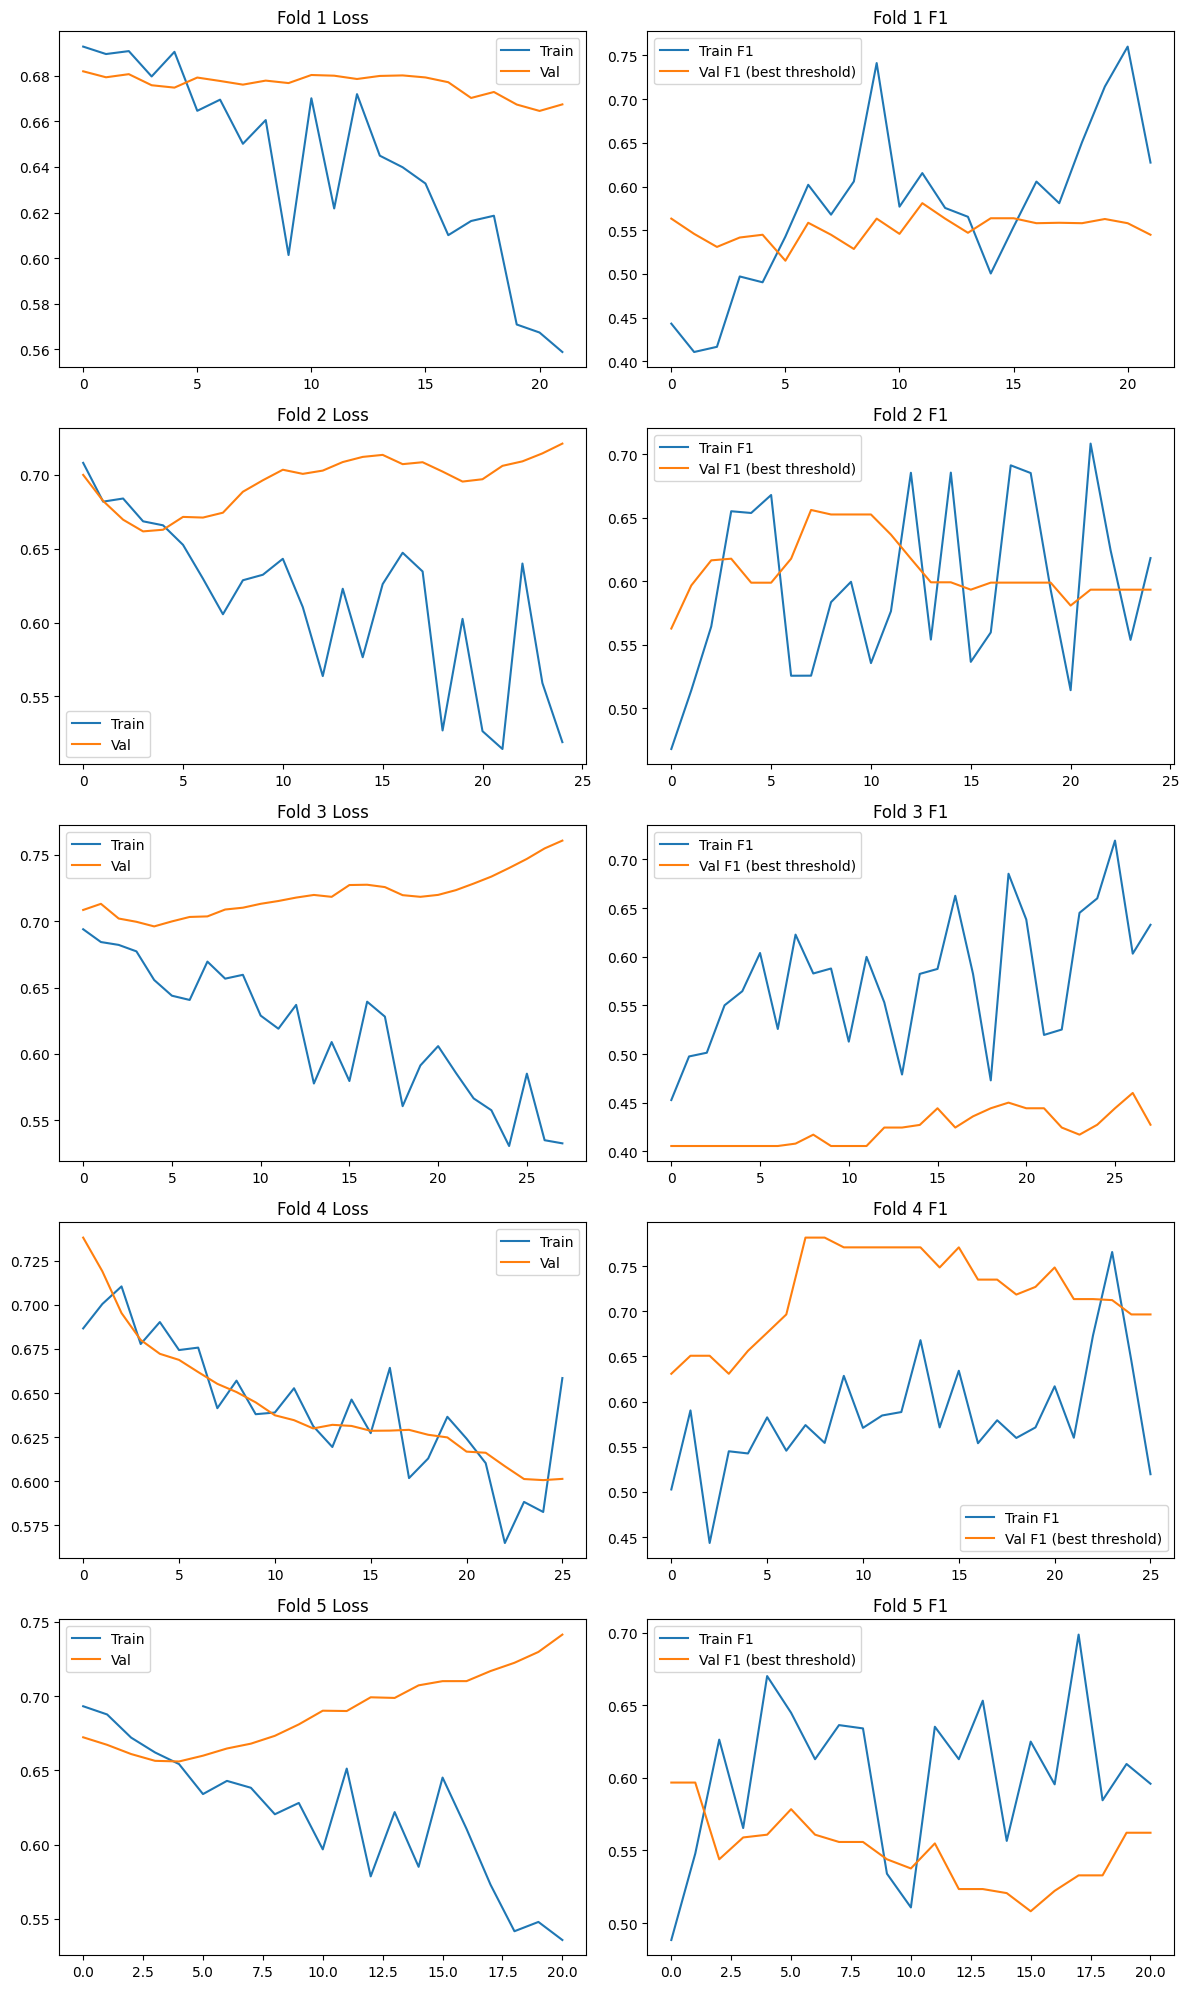

In [20]:
# Train Classifier 3 (Aggressive Subtypes)
preds_c3, le_c3 = train_classifier('C3_AGGRESSIVE_SUBTYPE', DF_FINAL, PRECOMPUTED_DIR)

In [21]:
# ---- C3 label distribution check ----
label_col = 'C3_label'

print("\n=== C3 AGGRESSIVE SUBTYPE: Label Distribution ===")
counts = DF_FINAL[label_col].value_counts().sort_index()

for cls in [-1, 0, 1]:
    print(f"Class {cls}: {counts.get(cls, 0)} samples")

print("\nMeaning:")
print("  0 → HER2(+)")
print("  1 → Triple Negative")
print(" -1 → Non-aggressive (Luminal)")
# 0 ≈ 150

# 1 ≈ 69

# -1 ≈ 362


=== C3 AGGRESSIVE SUBTYPE: Label Distribution ===
Class -1: 362 samples
Class 0: 150 samples
Class 1: 69 samples

Meaning:
  0 → HER2(+)
  1 → Triple Negative
 -1 → Non-aggressive (Luminal)


# SUBMISSION

In [22]:
# --- ADD THIS TO YOUR GLOBAL CONSTANTS SECTION ---
TEST_PRECOMPUTED_DIR = '/kaggle/working/precomputed_rois_test'

DF_TEST_PROCESSED = None

In [23]:
# --- New Function: Setup Test Data and Preprocess Images ---
def setup_test_data_and_preprocess():
    """
    Finds test image files, runs the heavy CPU precomputation (ROI extraction and 
    Reinhard normalization), and returns the DataFrame of successfully processed test images.
    """
    print("--- 🧠 Test Data Setup & Preprocessing Started ---")
    
    # 1. List Test Files
    test_files = [f for f in os.listdir(PATHS['test_img']) if f.endswith('.png')]
    # Create a DataFrame required by preprocess_and_save_images
    test_df = pd.DataFrame({'sample_index': test_files})
    
    # 2. Precompute ROIs, Resize, and Save (Reusing the core logic)
    # We must adapt the existing 'preprocess_and_save_images' slightly 
    # to accept dynamic image/mask paths since it was hardcoded for 'train_img'/'train_mask'.
    
    # --- TEMPORARY FIX: Override PATHS for test processing ---
    # We temporarily create a local path structure that preprocess_and_save_images can use.
    local_paths = {
        'train_img': PATHS['test_img'],    # Source folder for images
        'train_mask': PATHS['test_mask']   # Source folder for masks
    }

    # You must update preprocess_and_save_images in your code to accept and use this local_paths dict
    # (assuming it uses the 'train_img'/'train_mask' keys internally).
    
    df_test_final = preprocess_and_save_images(
        df=test_df, 
        paths=local_paths, # Pass the test paths
        output_dir=TEST_PRECOMPUTED_DIR, 
        img_size=IMG_SIZE
    )
    
    print(f"--- ✅ Test Precomputation Complete. Final test images available: {len(df_test_final)} ---")
    return df_test_final

In [24]:
# --- NEW: Function to Check/Run Test Preprocessing Once ---
def get_processed_test_data():
    """
    Checks if the test data has been processed. If not, runs the heavy preprocessing 
    and stores the resulting DataFrame globally.
    """
    global DF_TEST_PROCESSED
    
    if DF_TEST_PROCESSED is None:
        print("--- ⏳ First call: Running Test Data Preprocessing ---")
        # Call your existing function that does the work (and includes the fix)
        DF_TEST_PROCESSED = setup_test_data_and_preprocess()
        
        if DF_TEST_PROCESSED.empty:
            raise ValueError("Test preprocessing returned an empty DataFrame. Cannot generate submission.")
        print(f"--- ✅ Test Data Stored. Total processed images: {len(DF_TEST_PROCESSED)} ---")
    else:
        print("--- ⏩ Skipping Test Preprocessing (Already done) ---")
        
    return DF_TEST_PROCESSED

In [25]:
# --- New Function: Prediction Helper (TTA + Ensemble for one task) ---
def predict_with_ensemble_tta(loader, model_prefix):
    """
    Loads 5 models (folds) for a specific task and computes the mean prediction
    using 4x TTA. Returns the raw logits/probabilities (for binary class 1).
    """
    models_list = []
    thresholds = []
    
    # Load 5 folds for the specific model_prefix (e.g., 'C1_TRIAGE_fold_i_best.pth')
    for i in range(N_FOLDS):
        model_path = f"{model_prefix}_fold_{i}_best.pth"

        try:
            from torch.serialization import safe_globals
            with safe_globals(["scalar"]):
                ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)

            
            m = get_model(num_classes=1)
            
            # If checkpoint is full state_dict
            if isinstance(ckpt, dict) and "state_dict" in ckpt:
                m.load_state_dict(ckpt["state_dict"])
                thresholds.append(ckpt.get("threshold", 0.5))
            else:
                m.load_state_dict(ckpt)
                thresholds.append(0.5)  # default threshold if not stored
                print(f"the threshold not stored for {model_prefix}_fold_{i}_best")

            m.eval().to(DEVICE)
            models_list.append(m)

        except FileNotFoundError:
            print(f"Warning: Model file not found: {model_path}. Skipping.")
            continue
        except Exception as e:
            print(f"Error loading fold {i} for {model_prefix}: {e}")
            continue

    if not models_list:
        raise ValueError(f"No models found for {model_prefix}. Did you train them first?")

    mean_threshold = float(np.mean(thresholds))
    print(f"{len(models_list)}/{N_FOLDS} folds loaded for {model_prefix}, mean threshold: {mean_threshold:.3f}")

    # --- Compute predictions with TTA ---
    all_preds = []
    all_logits = []
    
    with torch.no_grad():
        for imgs, names in tqdm(loader, desc=f"Predicting {model_prefix} (TTA/Ens)"):
            imgs = imgs.to(DEVICE)

            # --- TTA: 4 Views (Original, FlipH, FlipV, Rot90) ---
            imgs_lr = torch.flip(imgs, [3])
            imgs_ud = torch.flip(imgs, [2])
            imgs_rot = torch.rot90(imgs, 1, [2, 3])

            inputs = [imgs, imgs_lr, imgs_ud, imgs_rot]

            batch_logits = torch.zeros((imgs.size(0), 1), device=DEVICE)

            # Ensemble over folds + TTA
            for m in models_list:
                for inp in inputs:
                    batch_logits += m(inp)

            batch_logits /= (len(models_list) * len(inputs))
            all_logits.append(batch_logits.squeeze(1).cpu())

    return torch.cat(all_logits, dim=0), mean_threshold


In [26]:
# --- 7. SUBMISSION (Hierarchical Prediction & TTA/Ensemble) ---
def submit():
    print("--- ⚙️ Generating Submission with Hierarchical TTA/Ensemble ---")
    
    # --- A. DATA SETUP ---

    df_test_processed = get_processed_test_data()
    
    if df_test_processed.empty:
        raise ValueError("Test preprocessing returned an empty DataFrame. Cannot generate submission.")
        
    
    # 2. Setup DataLoader using the processed DataFrame and the correct path
    test_ds = TissueDataset(
        dataframe=df_test_processed,                              # FIX: Use 'dataframe' instead of 'df'
        precomputed_dir=TEST_PRECOMPUTED_DIR,                     # FIX: Use 'precomputed_dir' instead of 'img_dir'
        transform=get_transforms()[1],                            # Validation/Test transforms
        is_test=True, 
        target_label_column='sample_index'                        # Target column is irrelevant for test
    )
    
    loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    # --- B. HIERARCHICAL PREDICTION (C1 -> C2/C3) ---
    
    # 1. Classify C1 (Triage: Luminal Group vs. Aggressive Group)
    # The prefix is the key from CLASSIFIER_CONFIGS
    logits_c1, t_c1 = predict_with_ensemble_tta(loader, 'C1_TRIAGE')
    preds_c1 = (torch.sigmoid(logits_c1) >= t_c1).long()

    
    
    # 2. Classify C2 (Luminal Subtypes) and C3 (Aggressive Subtypes)
    
    # Initialize the final result array (will hold the final 4-class prediction)
    final_4class_preds = torch.zeros_like(preds_c1, device=DEVICE) # Initialize on device
    
    # --- C2: Predict on Luminal Group (where C1_pred == 0) ---
    luminal_indices = (preds_c1 == 0).nonzero(as_tuple=True)[0]
    
    if len(luminal_indices) > 0:
        # FIX 1: Use df_test_processed instead of undefined test_df
        luminal_df = df_test_processed.iloc[luminal_indices].reset_index(drop=True)
        # FIX 2: C2 prediction must read from TEST_PRECOMPUTED_DIR, not PRECOMPUTED_DIR (which is for train)
        luminal_ds = TissueDataset(
            dataframe=luminal_df, 
            precomputed_dir=TEST_PRECOMPUTED_DIR, 
            transform=get_transforms()[1], 
            is_test=True
        )
        luminal_loader = DataLoader(luminal_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        
        logits_c2, t_c2 = predict_with_ensemble_tta(luminal_loader, 'C2_LUMINAL_SUBTYPE')
        # preds_c2 = (torch.sigmoid(logits_c2) >= t_c2).long()

        # # Mapping: Luminal A (0) is original class 0, Luminal B (1) is original class 1
        # # The final index must be placed back into the final_4class_preds array
        # final_4class_preds[luminal_indices] = preds_c2.to(DEVICE) # 0 or 1

        probs_c2 = torch.sigmoid(logits_c2)  # raw probabilities

        # --- DISTRIBUTION MATCHING ---
        n_luminal = len(probs_c2)
        # target proportions for Luminal A/B from training
        target_props = np.array([158, 204]) / (158 + 204)
        n_luminal_A = int(target_props[0] * n_luminal)
        n_luminal_B = n_luminal - n_luminal_A
        
        sorted_idx = np.argsort(probs_c2.cpu().numpy())
        final_c2_preds = torch.zeros_like(probs_c2, device=DEVICE)
        final_c2_preds[sorted_idx[-n_luminal_B:]] = 1  # top probabilities -> B
        final_c2_preds[sorted_idx[:n_luminal_A]] = 0   # bottom probabilities -> A
        
        #final_4class_preds[luminal_indices] = final_c2_preds
        final_4class_preds[luminal_indices] = final_c2_preds.long()


    
    # --- C3: Predict on Aggressive Group (where C1_pred == 1) ---
    aggressive_indices = (preds_c1 == 1).nonzero(as_tuple=True)[0]
    
    if len(aggressive_indices) > 0:
            # FIX 3: Use df_test_processed instead of undefined test_df
            aggressive_df = df_test_processed.iloc[aggressive_indices].reset_index(drop=True)
            # FIX 4: C3 prediction must read from TEST_PRECOMPUTED_DIR, not PRECOMPUTED_DIR (which is for train)
            aggressive_ds = TissueDataset(
                dataframe=aggressive_df, 
                precomputed_dir=TEST_PRECOMPUTED_DIR, 
                transform=get_transforms()[1], 
                is_test=True
            )
            aggressive_loader = DataLoader(aggressive_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
            
            logits_c3, t_c3 = predict_with_ensemble_tta(aggressive_loader, 'C3_AGGRESSIVE_SUBTYPE')
            # preds_c3 = (torch.sigmoid(logits_c3) >= t_c3).long()

            # # Shift binary prediction by +2: 0->2, 1->3
            # final_4class_preds[aggressive_indices] = preds_c3.to(DEVICE) + 2
            probs_c3 = torch.sigmoid(logits_c3)  # raw probabilities
            
            # --- DISTRIBUTION MATCHING ---
            n_aggressive = len(probs_c3)
            # target proportions for HER2(+)/TN from training
            target_props = np.array([150, 69]) / (150 + 69)
            n_her2 = int(target_props[0] * n_aggressive)
            n_tn = n_aggressive - n_her2
            
            sorted_idx = np.argsort(probs_c3.cpu().numpy())
            final_c3_preds = torch.zeros_like(probs_c3, device=DEVICE)
            final_c3_preds[sorted_idx[-n_tn:]] = 1  # top probabilities -> TN
            final_c3_preds[sorted_idx[:n_her2]] = 0 # bottom probabilities -> HER2(+)
            
            #final_4class_preds[aggressive_indices] = final_c3_preds + 2
            final_4class_preds[aggressive_indices] = (final_c3_preds + 2).long()

            
                    
    
    # --- C. FINAL OUTPUT MAPPING ---
    
    # Define the final 4 class names (ordered by the index 0, 1, 2, 3)
    FINAL_4CLASS_NAMES = [
        'Luminal A',        # C2_pred == 0
        'Luminal B',        # C2_pred == 1
        'HER2(+)',          # C3_pred == 0 (index 2)
        'Triple negative'   # C3_pred == 1 (index 3)
    ]
    
    # Map the final numerical prediction (0, 1, 2, or 3) back to class strings
    final_labels_text = [FINAL_4CLASS_NAMES[i.item()] for i in final_4class_preds]
    
    # Create Submission File
    submission_df = pd.DataFrame({
        'sample_index': df_test_processed['sample_index'], # Filenames from test_df
        'label': final_labels_text
    })

    # ---- SORT BY SAMPLE INDEX ----
    submission_df['order_id'] = (
        submission_df['sample_index']
        .str.replace('img_', '', regex=False)
        .str.replace('.png', '', regex=False)
        .astype(int)
    )
    
    submission_df = submission_df.sort_values('order_id').reset_index(drop=True)
    submission_df.drop(columns='order_id', inplace=True)

    #save
    submission_df.to_csv('check.csv', index=False)
    print("Done. Submission file 'submission.csv' created.")

    # --- Print class distribution ---
    print("\n=== Submission Class Distribution ===")
    print(submission_df['label'].value_counts())
    
    # Optionally, also show percentages
    total = len(submission_df)
    distribution_pct = (submission_df['label'].value_counts() / total * 100).round(2)
    print("\n=== Submission Class Distribution (%) ===")
    print(distribution_pct)

    return submission_df

In [27]:
submit()

--- ⚙️ Generating Submission with Hierarchical TTA/Ensemble ---
--- ⏳ First call: Running Test Data Preprocessing ---
--- 🧠 Test Data Setup & Preprocessing Started ---
Starting precomputation and saving of processed ROIs...


Preprocessing Images: 100%|██████████| 477/477 [00:59<00:00,  8.00it/s]


--- ✅ Test Precomputation Complete. Final test images available: 477 ---
--- ✅ Test Data Stored. Total processed images: 477 ---
5/5 folds loaded for C1_TRIAGE, mean threshold: 0.506


Predicting C1_TRIAGE (TTA/Ens): 100%|██████████| 8/8 [00:13<00:00,  1.73s/it]


5/5 folds loaded for C2_LUMINAL_SUBTYPE, mean threshold: 0.528


Predicting C2_LUMINAL_SUBTYPE (TTA/Ens): 100%|██████████| 6/6 [00:09<00:00,  1.66s/it]


5/5 folds loaded for C3_AGGRESSIVE_SUBTYPE, mean threshold: 0.506


Predicting C3_AGGRESSIVE_SUBTYPE (TTA/Ens): 100%|██████████| 3/3 [00:04<00:00,  1.54s/it]

Done. Submission file 'submission.csv' created.

=== Submission Class Distribution ===
label
Luminal B          188
Luminal A          144
HER2(+)             99
Triple negative     46
Name: count, dtype: int64

=== Submission Class Distribution (%) ===
label
Luminal B          39.41
Luminal A          30.19
HER2(+)            20.75
Triple negative     9.64
Name: count, dtype: float64


,sample_index,label
0,img_0000.png,Luminal A
1,img_0001.png,Luminal A
2,img_0002.png,Luminal B
3,img_0003.png,Triple negative
4,img_0004.png,Luminal B
...,...,...
472,img_0472.png,Triple negative
473,img_0473.png,HER2(+)
474,img_0474.png,Luminal B
475,img_0475.png,Luminal B
